# Task 2: Building Supervised Models

Comparing **Logistic Regression**, **Decision Tree**, and **SVM** on the Breast Cancer Wisconsin dataset using scikit-learn.

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

## 2. Load the Dataset

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print(X.shape)
print(dict(zip(data.target_names, [0, 1])))
print(X.isnull().sum().sum())

(569, 30)
{np.str_('malignant'): 0, np.str_('benign'): 1}
0


## 3. Preview the Data

In [3]:
X.head()

   mean radius  mean texture  ...  worst symmetry  worst fractal dimension
0        17.99         10.38  ...          0.4601                  0.11890
1        20.57         17.77  ...          0.2750                  0.08902
2        19.69         21.25  ...          0.3613                  0.08758
3        11.42         20.38  ...          0.6638                  0.17300
4        20.29         14.34  ...          0.2364                  0.07678

[5 rows x 30 columns]

## 4. Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 5. Feature Scaling

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Define the Models

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
}

## 7. Train and Evaluate Each Model

In [7]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
results_df

                 Model  Accuracy  Precision    Recall  F1 Score
2                  SVM  0.982456   0.972603  1.000000  0.986111
0  Logistic Regression  0.973684   0.972222  0.985915  0.979021
1        Decision Tree  0.947368   0.957746  0.957746  0.957746

## 8. Visualize Model Comparison

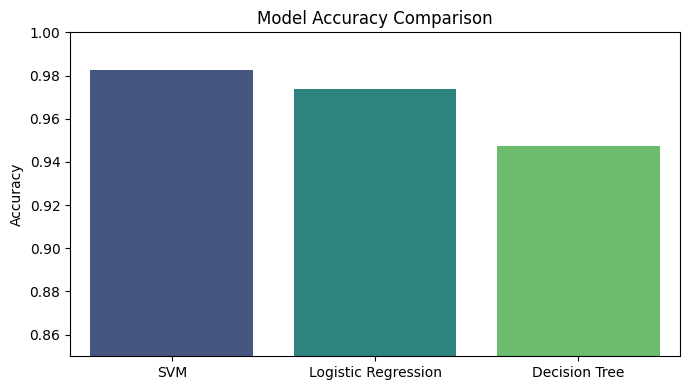

In [8]:
plt.figure(figsize=(7, 4))
sns.barplot(data=results_df, x="Model", y="Accuracy", hue="Model", palette="viridis", legend=False)
plt.ylim(0.85, 1.0)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("")
plt.tight_layout()
plt.show()

## 9. Best Model

In [9]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print(best_model_name)

SVM


## 10. Confusion Matrix for the Best Model

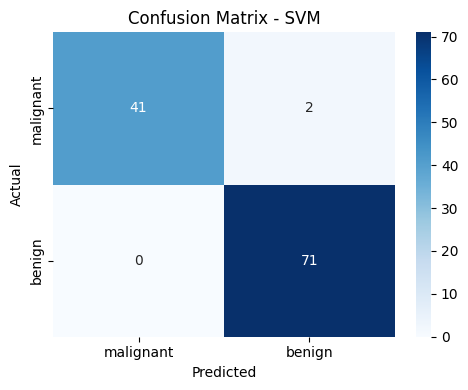

In [10]:
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 11. Feature Importance (Decision Tree)

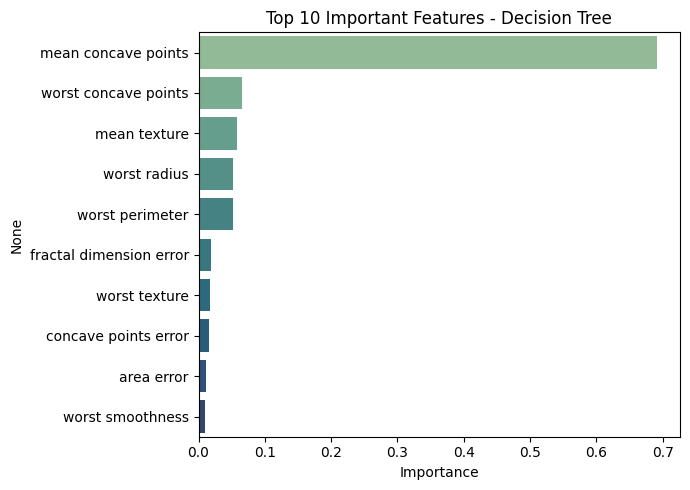

In [11]:
importances = pd.Series(models["Decision Tree"].feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(7, 5))
sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, palette="crest", legend=False)
plt.title("Top 10 Important Features - Decision Tree")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 12. Validate with Sample Test Cases

In [12]:
sample = X_test_scaled[:5]
sample_true = y_test.iloc[:5].values
sample_pred = best_model.predict(sample)

for i in range(5):
    label_true = data.target_names[sample_true[i]]
    label_pred = data.target_names[sample_pred[i]]
    match = "correct" if sample_true[i] == sample_pred[i] else "WRONG"
    print(f"True: {label_true:10s} | Predicted: {label_pred:10s} | {match}")

True: benign     | Predicted: benign     | correct
True: malignant  | Predicted: malignant  | correct
True: malignant  | Predicted: malignant  | correct
True: benign     | Predicted: benign     | correct
True: benign     | Predicted: benign     | correct
